In [106]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display, Image
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
import os


def render(tex_code, output):
    tex_filename = "circuit.tex"
    with open(tex_filename, "w") as f:
        f.write(tex_code)
    os.system(f"pdflatex -interaction=nonstopmode -halt-on-error {tex_filename} > /dev/null 2>&1")
    os.system(f"pdftocairo -png -singlefile circuit.pdf {output :-4 } > /dev/null 2>&1")
    for ext in  ".tex", ".aux", ".log", ".pdf" :
        try:
            os.remove(f"circuit{ext}")
        except FileNotFoundError:
            pass







u = 0.05

# Wechselstrom II <br> Messungen mit dem Oszilloskop

## Bestimmung eines unbekannten Widerstands mit dem Oszilloskop

In diesem Experiment wird ein unbekannter ohmscher Widerstand $R_x$, Spule $X_L$ und Kondensator $X_C$ mithilfe eines Funktionsgenerators und eines Digital-Oszilloskops bestimmt, indem die Gesamtspannung $U_1$ und die Teilspannung $U_2$ über einem bekannten Widerstand $R_0$ gemessen werden.

### Durchführung und Versuchsaufbau

Ein bekannter Widerstand $R_0$ und ein unbekannter Widerstand $R_x$ werden in Serie geschaltet.  
Die Gesamtspannung $U_1(t)$ legt man mit einem Funktionsgenerator (Spannung bei $\nu = 500\,\text{Hz}$) an. Die Teilspannung über dem bekannten Widerstand $R_0$, also $U_2(t)$, wird an Kanal 2 gemessen.

Die Spitze-Spitze-Werte $U_{1,pp}$ und $U_{2,pp}$ werden am Oszilloskops abgelesen. Für rein ohmsche Widerstände:

$$
R_x = R_0\left( \frac{U_1}{U_2} - 1 \right)
$$

die Phasenverschiebung beträgt:

$$
\Delta\varphi = 0.
$$

$R_x$ wird durch einen Kondensator ersetzt. Die Messung erfolgt bei einer Frequenz von ca. $150\,\text{Hz}$.

Der kapazitive Widerstand ergibt sich zu:

$$
X_C = R_0 \sqrt{\left( \frac{U_1}{U_2} \right)^2 - 1}
$$

und die Kapazität zu:

$$
C = \frac{1}{\omega X_C}.
$$

Die Phasenverschiebung folgt aus:

$$
\Delta\varphi = \arctan\!\left(\frac{X_C}{R_0}\right),
$$

Der Kondensator wird durch eine Spule ersetzt und bei einer Frequenz von etwa $30\,\text{kHz}$ die spannung gemessen.

Der induktive Widerstand beträgt:

$$
X_L = R_0 \sqrt{\left( \frac{U_1}{U_2} \right)^2 - 1}
$$

und daraus ergibt sich die Induktivität:

$$
L = \frac{X_L}{\omega}.
$$

Die Phasenverschiebung folgt wieder aus

$$
\Delta\varphi = \arctan\!\left(\frac{X_L}{R_0}\right),
$$

Dabei wird für die Messung folgende Formel benutzt:


$$
\Delta\varphi = \frac{\Delta t}{T},
$$


### Verwendete Geräte

**Oszilloskop Tektronix TBS 1072B**  

**Funktionsgenerator**  


### Systematische Unsicherheiten

Die systematischen Unsicherheiten resultieren vor allem aus nicht-idealen Eigenschaften der Bauelemente. Die Spule besitzt einen ohmschen Drahtwiderstand, der den wirksamen $X_L$ leicht verfälscht und die Phasenverschiebung zu klein erscheinen lässt. 


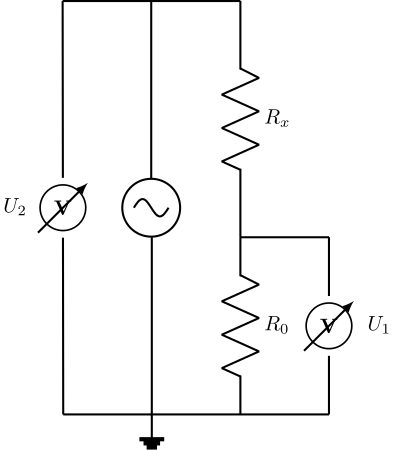

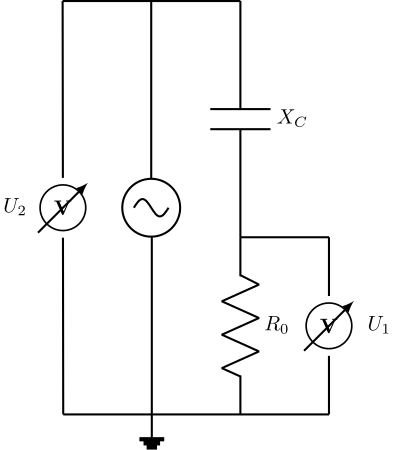

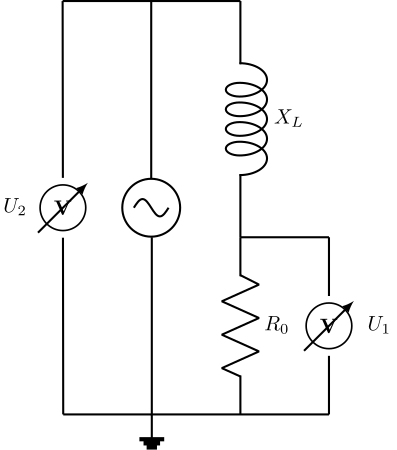

In [107]:
display(Image("Rx.png"))
display(Image("Kondensator.png"))
display(Image("Spule.png"))

In [178]:

R0 = 1770                                                   # Ohm 

# Rx
fr = 500                                                    # Hz 
U1r = 10.0                                                  # V 
U2r = 2.32                                                  # V 

Rx = (R0*((U1r/U2r)-1))*1e-3
Rx = ufloat(Rx, Rx*u)                                       # mit Unsicherheit
φr = 0


# C
fc = 150                                                    # Hz 
wc = 2 * np.pi * fc                                         # rad/s 

U1c = 10.0                                                  # V 
U2c = 3.40                                                  # V 
tc = 1.36*1e-3                                              # s 
Tc = 1/fc

Xc = R0 * np.sqrt(((U1c/U2c)**2)-1)                    # Ohm 
Xc = ufloat(Xc, Xc*u)                                       # Ohm 
c = (1/(wc*Xc))                                         # F # GEMESSENER wert 231
φc = tc/Tc                                                  # berechnete Phasenverschiebung  rad 
φc = ufloat(φc, φc*u)
φc_grad = unp.degrees(φc)                                   # berechnete Phasenverschiebung in grad

phi_c = unp.arctan(Xc/R0)


# L                 # 0.565 V
fl = 30 * 10**3                                             # Hz 
wl = 2 * np.pi * fl                                         # rad/s 
tl = 4.8*1e-6                                              # s 
Tl = 1/fl


U1l = 10.8                                                # V 
U2l = 6.8                                                  # V 

Xl = R0 * np.sqrt(((U1l/U2l)**2)-1)                         # Ohm 
Xl = ufloat(Xl, Xl*u)                                       # Ohm 
L = ((Xl/wl))                                             # H                                          # F 
φl = tl/Tl                                                 # berechnete Phasenverschiebung  rad 
φl = ufloat(φl, φl*u)
φl_grad = unp.degrees(φl)                                   # berechnete Phasenverschiebung in grad

phi_l = unp.arctan(Xl/R0)

display(Latex(rf"$$R_0 = ({R0:.2f})\Omega$$"))



# Rx

display(Latex(rf"$$\mathrm{{\huge{{Ohmscher~Widerstand}}}}$$"))

display(Latex(rf"$$R_x = ({Rx:.2f})\Omega$$"))

display(Latex(rf"$$\Delta \phi = ({0:.2f})°$$"))


# C
display(Latex(rf"$$\mathrm{{\huge{{Kapazativer~Widerstand}}}}$$"))


display(Latex(rf"$$X_c = ({Xc:.2f})\Omega$$"))

display(Latex(rf"$$C = ({c*1e6:.2f})\mathrm \mu F$$"))


display(Latex(rf"$$\Delta \phi_{{gemessen}} = ({φc:.2f})° = {φc_grad:.2f}$$"))
display(Latex(rf"$$\Delta \phi_{{berechnet}} = {phi_c:.2f}$$"))



# L
display(Latex(rf"$$\mathrm{{\huge{{Induktiver~Widerstand}}}}$$"))



display(Latex(rf"$$X_l = ({Xl:.2f})\Omega$$"))

display(Latex(rf"$$L = ({L*1e3:.2f})\mathrm mH$$"))


display(Latex(rf"$$\Delta \phi_{{gemessen}} = ({φl:.2f})° = {φl_grad:.2f}$$"))

display(Latex(rf"$$\Delta \phi_{{berechnet}} = {phi_l:.2f}$$"))




<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

...

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>